## Wine Quality Prediction

**Description:**

The focus is on predicting the quality of wine based on its chemical characteristics, offering a real-world application of machine learning in the context of viticulture.The dataset encompasses diverse chemical attributes,including density and acidity,which serve as the features for three distinct classifier models.

In [1]:
# Importing Libraries:
# Import pandas library for data manupulation or analysis
import pandas as pd

# Import Numpy library for numeric calculation
import numpy as np

# Import the libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Inorder to Supress the Warnings Import Filterwarnings:
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Import the dataset
df = pd.read_csv('WineQT.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


**Interpretation :** Represent the dataset with rows and columns to proceed for further process.

In [3]:
# display head of the dataset:
# head() displays the first five rows:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
# display tail of the dataset:
# tail() displays the last five rows:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [5]:
# Size of the dataset:
df.shape

(1143, 13)

**Interpretation :** Shape of the dataset includes how many rows and how many columns are exist in our dataset.The given dataset contains 1143 rows and 13 columns

In [6]:
# check the variable type:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [7]:
# Check for the count of columns 
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

**Interpretation :** Represents all column names present in our dataset

In [8]:
# check for duplicates:
df.duplicated().sum()

0

**Interpretation :** The dataset have no duplicated values

In [9]:
# Check for null values:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

**Interpretation :** The dataset has no null values

In [10]:
# Sum of total null values:
df.isnull().sum().sum()

0

In [11]:
# Descriptive Statistics:

# Summary of numerical variables
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


**Interpretation :** Represents the five point summary about the dataset which includes mean,min,max,standard deviation and count for numerical columns

In [12]:
# skewness of the data:
df.skew()

fixed acidity           1.044930
volatile acidity        0.681547
citric acid             0.371561
residual sugar          4.361096
chlorides               6.026360
free sulfur dioxide     1.231261
total sulfur dioxide    1.665766
density                 0.102395
pH                      0.221138
sulphates               2.497266
alcohol                 0.863313
quality                 0.286792
Id                     -0.010419
dtype: float64

**Interpretation :** All columns in the given dataset are positively Skewed.

In [13]:
# Kurtosis for entire dataset:
df.kurt()

fixed acidity            1.384614
volatile acidity         1.375531
citric acid             -0.714686
residual sugar          27.675366
chlorides               47.078324
free sulfur dioxide      1.932170
total sulfur dioxide     5.098748
density                  0.888123
pH                       0.925791
sulphates               12.017377
alcohol                  0.221179
quality                  0.314664
Id                      -1.216364
dtype: float64

**Interpretation :** The variables in the dataset having positive values, hence we conclude that it is a Leptokurtic

In [14]:
# Covarience:
cov = df.cov()
cov

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,3.054088,-0.078710,0.231382,0.407169,0.008912,-2.952729,-6.337887,0.002293,-0.187587,0.051991,-0.141947,0.171765,-223.661744
volatile acidity,-0.078710,0.032268,-0.019227,-0.001401,0.000478,-0.003614,0.457838,0.000006,0.006233,-0.008451,-0.039640,-0.058971,-0.657757
citric acid,0.231382,-0.019227,0.038685,0.046888,0.002281,-0.116107,0.237737,0.000142,-0.016835,0.011101,0.022616,0.038169,-12.686355
residual sugar,0.407169,-0.001401,0.046888,1.838512,0.004542,2.298013,8.480591,0.000992,-0.024845,0.004037,0.085725,0.024040,-29.157202
chlorides,0.008912,0.000478,0.002281,0.004542,0.002234,0.007404,0.074630,0.000019,-0.002057,0.003019,-0.011761,-0.004726,-1.932181
free sulfur dioxide,-2.952729,-0.003614,-0.116107,2.298013,0.007404,105.072466,222.148870,-0.001069,0.116914,0.060164,-0.522424,-0.522530,453.111245
total sulfur dioxide,-6.337887,0.457838,0.237737,8.480591,0.074630,222.148870,1074.668067,0.003166,-0.303657,0.150229,-6.675462,-4.843203,-1633.480285
density,0.002293,0.000006,0.000142,0.000992,0.000019,-0.001069,0.003166,0.000004,-0.000106,0.000047,-0.001031,-0.000272,-0.325068
pH,-0.187587,0.006233,-0.016835,-0.024845,-0.002057,0.116914,-0.303657,-0.000106,0.024544,-0.004952,0.038201,-0.006622,9.661029
sulphates,0.051991,-0.008451,0.011101,0.004037,0.003019,0.060164,0.150229,0.000047,-0.004952,0.029036,0.017412,0.035387,-8.219046


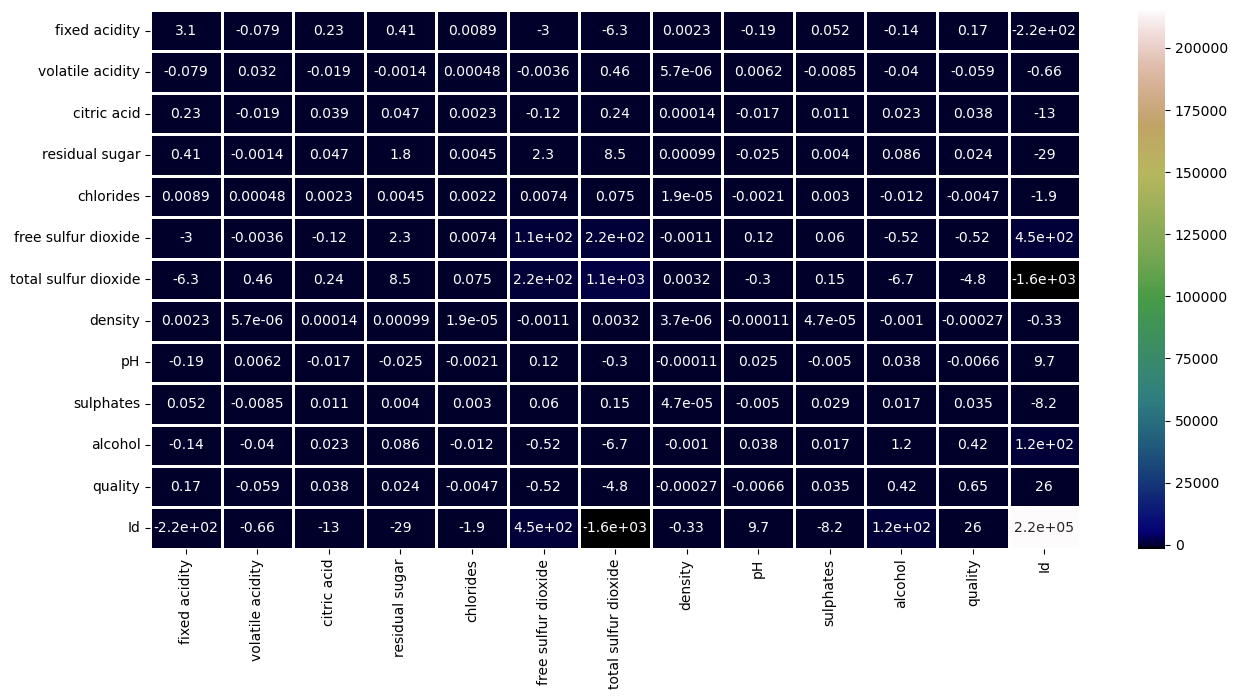

In [15]:
# covariance:
cov = df.cov()
cov

# set the figure size:
fig,ax = plt.subplots(figsize = (15,7))

# plot a Heatmap for the Covariance Matrix
# annot: print values in each cell
# Linewidths : specify width of the Line and specifying the plot
# vmin: minimum value of the variable
# vmax: maximum value of the variable
# Cmap: colour code for the plot
# fmt: set the decimal place of the Annot
sns.heatmap(cov,annot = True,linewidths = 0.95,
           cmap = 'gist_earth', fmt = '.2g')

# display the plot
plt.show()

In [16]:
# correlation:
corr = df.corr()
corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


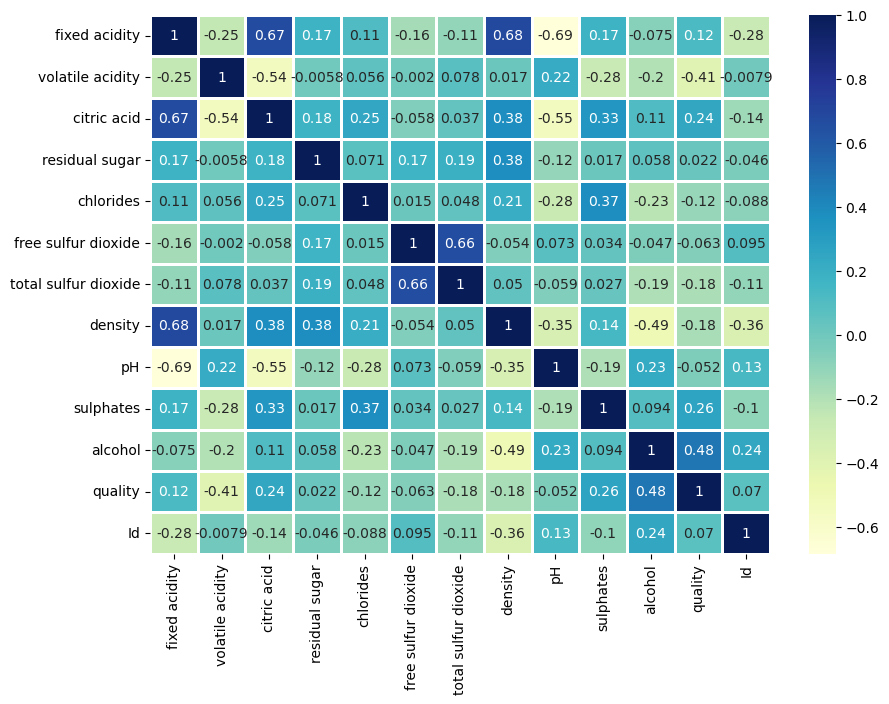

In [24]:
# correlation:
corr = df.corr()
corr

# set the figure size
fig,ax = plt.subplots(figsize = (10,7))

# plot a Heatmap for the Correlation Matrix
# annot: print values in each cell
# Linewidths : specify width of the Line and specifying the plot
# vmin: minimum value of the variable
# vmax: maximum value of the variable
# Cmap: colour code for the plot
# fmt: set the decimal place of the Annot
sns.heatmap(corr,annot = True,linewidths = 0.95,
           cmap = 'YlGnBu', fmt = '.2g')

# display the plot
plt.show()

### Univariate Analysis

In [18]:
# Considering the variable 'quality'
# check the number of observations in the data using the len()
Quality = df['quality']
print(len(Quality))

1143


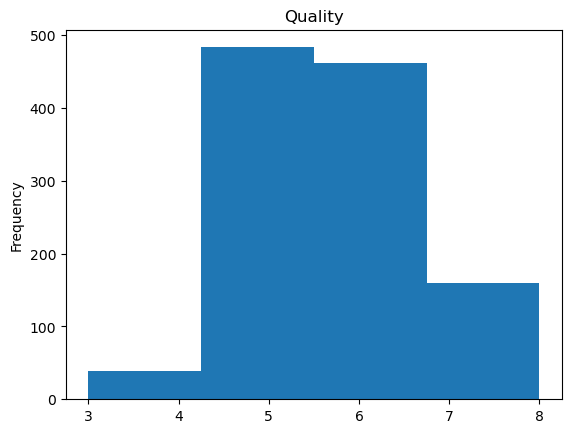

In [21]:
# Histogram for 'quality'
plt.hist(Quality,bins =4)

# set the title
plt.title('Quality')

# set the  y-label
plt.ylabel('Frequency')

# display the plot
plt.show()

**Interpretation :** The histogram divides the data into bins,counts the data points in each bin.It shows the bins on the x-axis and the counts on the y-axis

- The variable "Quality" has non symmetrical distribution

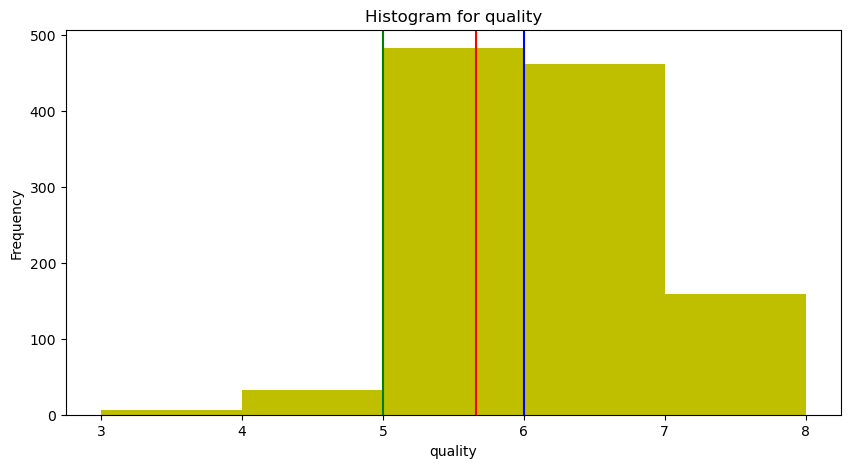

In [22]:
# set the figure size:
plt.figure(figsize = (10,5))

# bins -10, creates the class interval:
plt.hist(df['quality'], bins =5,color = 'y')

# plot the lines of the mean,median, and mode on the histogram plot:
# specify different colors for each line along by using the 'color' parameter
plt.axvline(df['quality'].mean(), color = 'red')
plt.axvline(df['quality'].median(), color = 'blue')
plt.axvline(df['quality'].mode()[0], color = 'green')

# set the title
plt.title('Histogram for quality')

# set the label for x-axis
plt.xlabel('quality')

# set the label for y-axis
plt.ylabel('Frequency')

# display the plot
plt.show()

In [34]:
Mean = df['quality'].mean()
Median = df['quality'].median()
Mode = df['quality'].mode()[0]

print('Mean:',round(Mean,2),'\n'
      'Median:',Median,'\n'
      'Mode:',Mode)

Mean: 10.44 
Median: 10.2 
Mode: 9.5


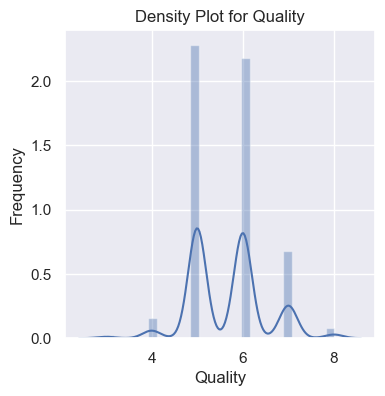

In [23]:
# set the figure size:
sns.set(style = 'darkgrid')
plt.rcParams['figure.figsize']=[4,4]

# Distplot() -- a plot for kernel density estimator:
sns.distplot(df['quality'])

# set the title:
plt.title('Density Plot for Quality')

# display the labels:
plt.xlabel('Quality')
plt.ylabel('Frequency')

# display the plot:
plt.show()

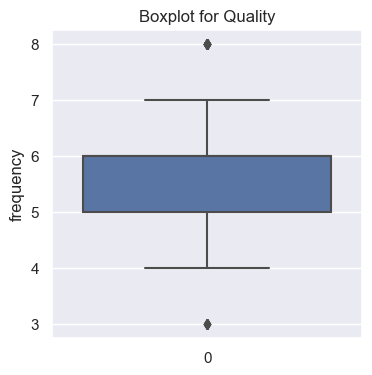

In [24]:
# Boxplot:
sns.boxplot(df['quality'])

# Display the labels:
plt.ylabel('frequency')
plt.title('Boxplot for Quality')

# Display the plot:
plt.show()

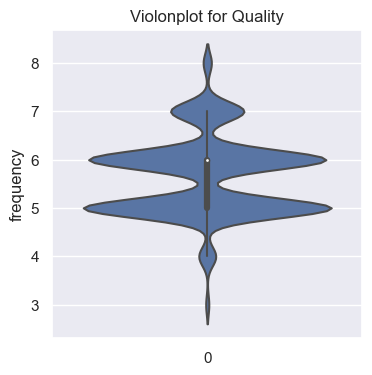

In [25]:
# Violin plot for quality:
sns.violinplot(df['quality'])

plt.ylabel('frequency')
plt.title('Violonplot for Quality')

plt.show()

### Bivariate Analysis

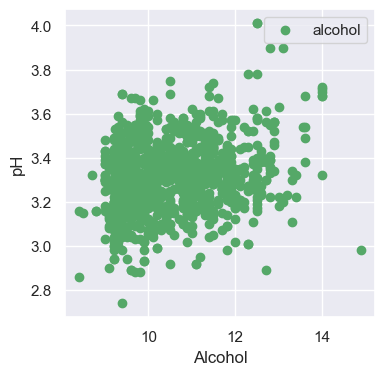

In [26]:
# Scatter Plot:
plt.scatter(x='alcohol',y='pH',label='alcohol',color='g',data=df)

# Display the labels:
plt.xlabel('Alcohol')
plt.ylabel('pH')

# display the headings:
plt.legend()

# Dispaly 
plt.show()

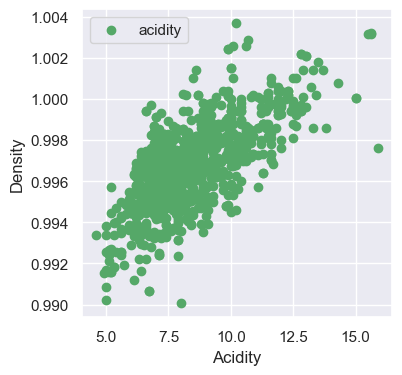

In [27]:
#  Scatter Plot:
plt.scatter(x='fixed acidity',y='density',label='acidity',color='g',data=df)

# Display the labels:
plt.xlabel('Acidity')
plt.ylabel('Density')

# Display the headings:
plt.legend()

# Display the plot:
plt.show()

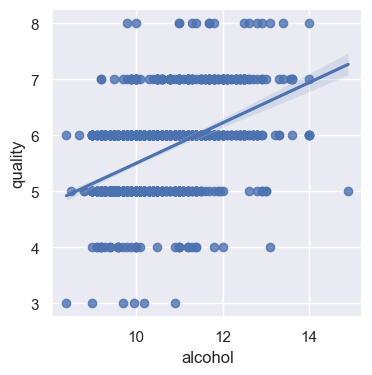

In [28]:
# Regression Plot:
sns.regplot(x='alcohol',y='quality',data=df)

# Display the plot:
plt.show()

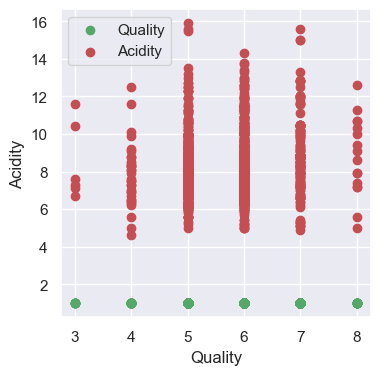

In [30]:
# Scatter plot:
plt.scatter(x='quality',y='density',label='Quality',color='g',data=df)
plt.scatter(x='quality',y='fixed acidity',label='Acidity',color='r',data=df)

# Set the labels:
plt.xlabel('Quality')
plt.ylabel('Acidity')

# Display the headings
plt.legend()

# Display the plot
plt.show()

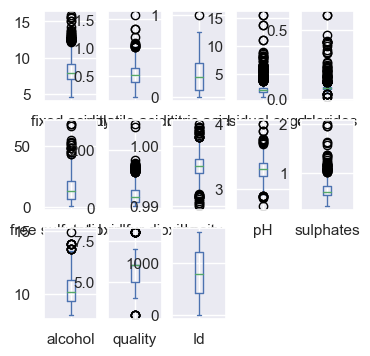

In [31]:
# Grounded box plot:
df.plot(kind = 'box',subplots = True,layout = (3,5))

# to give the secified padding from the subplot:
plt.tight_layout()

# displays the plot:
plt.show()

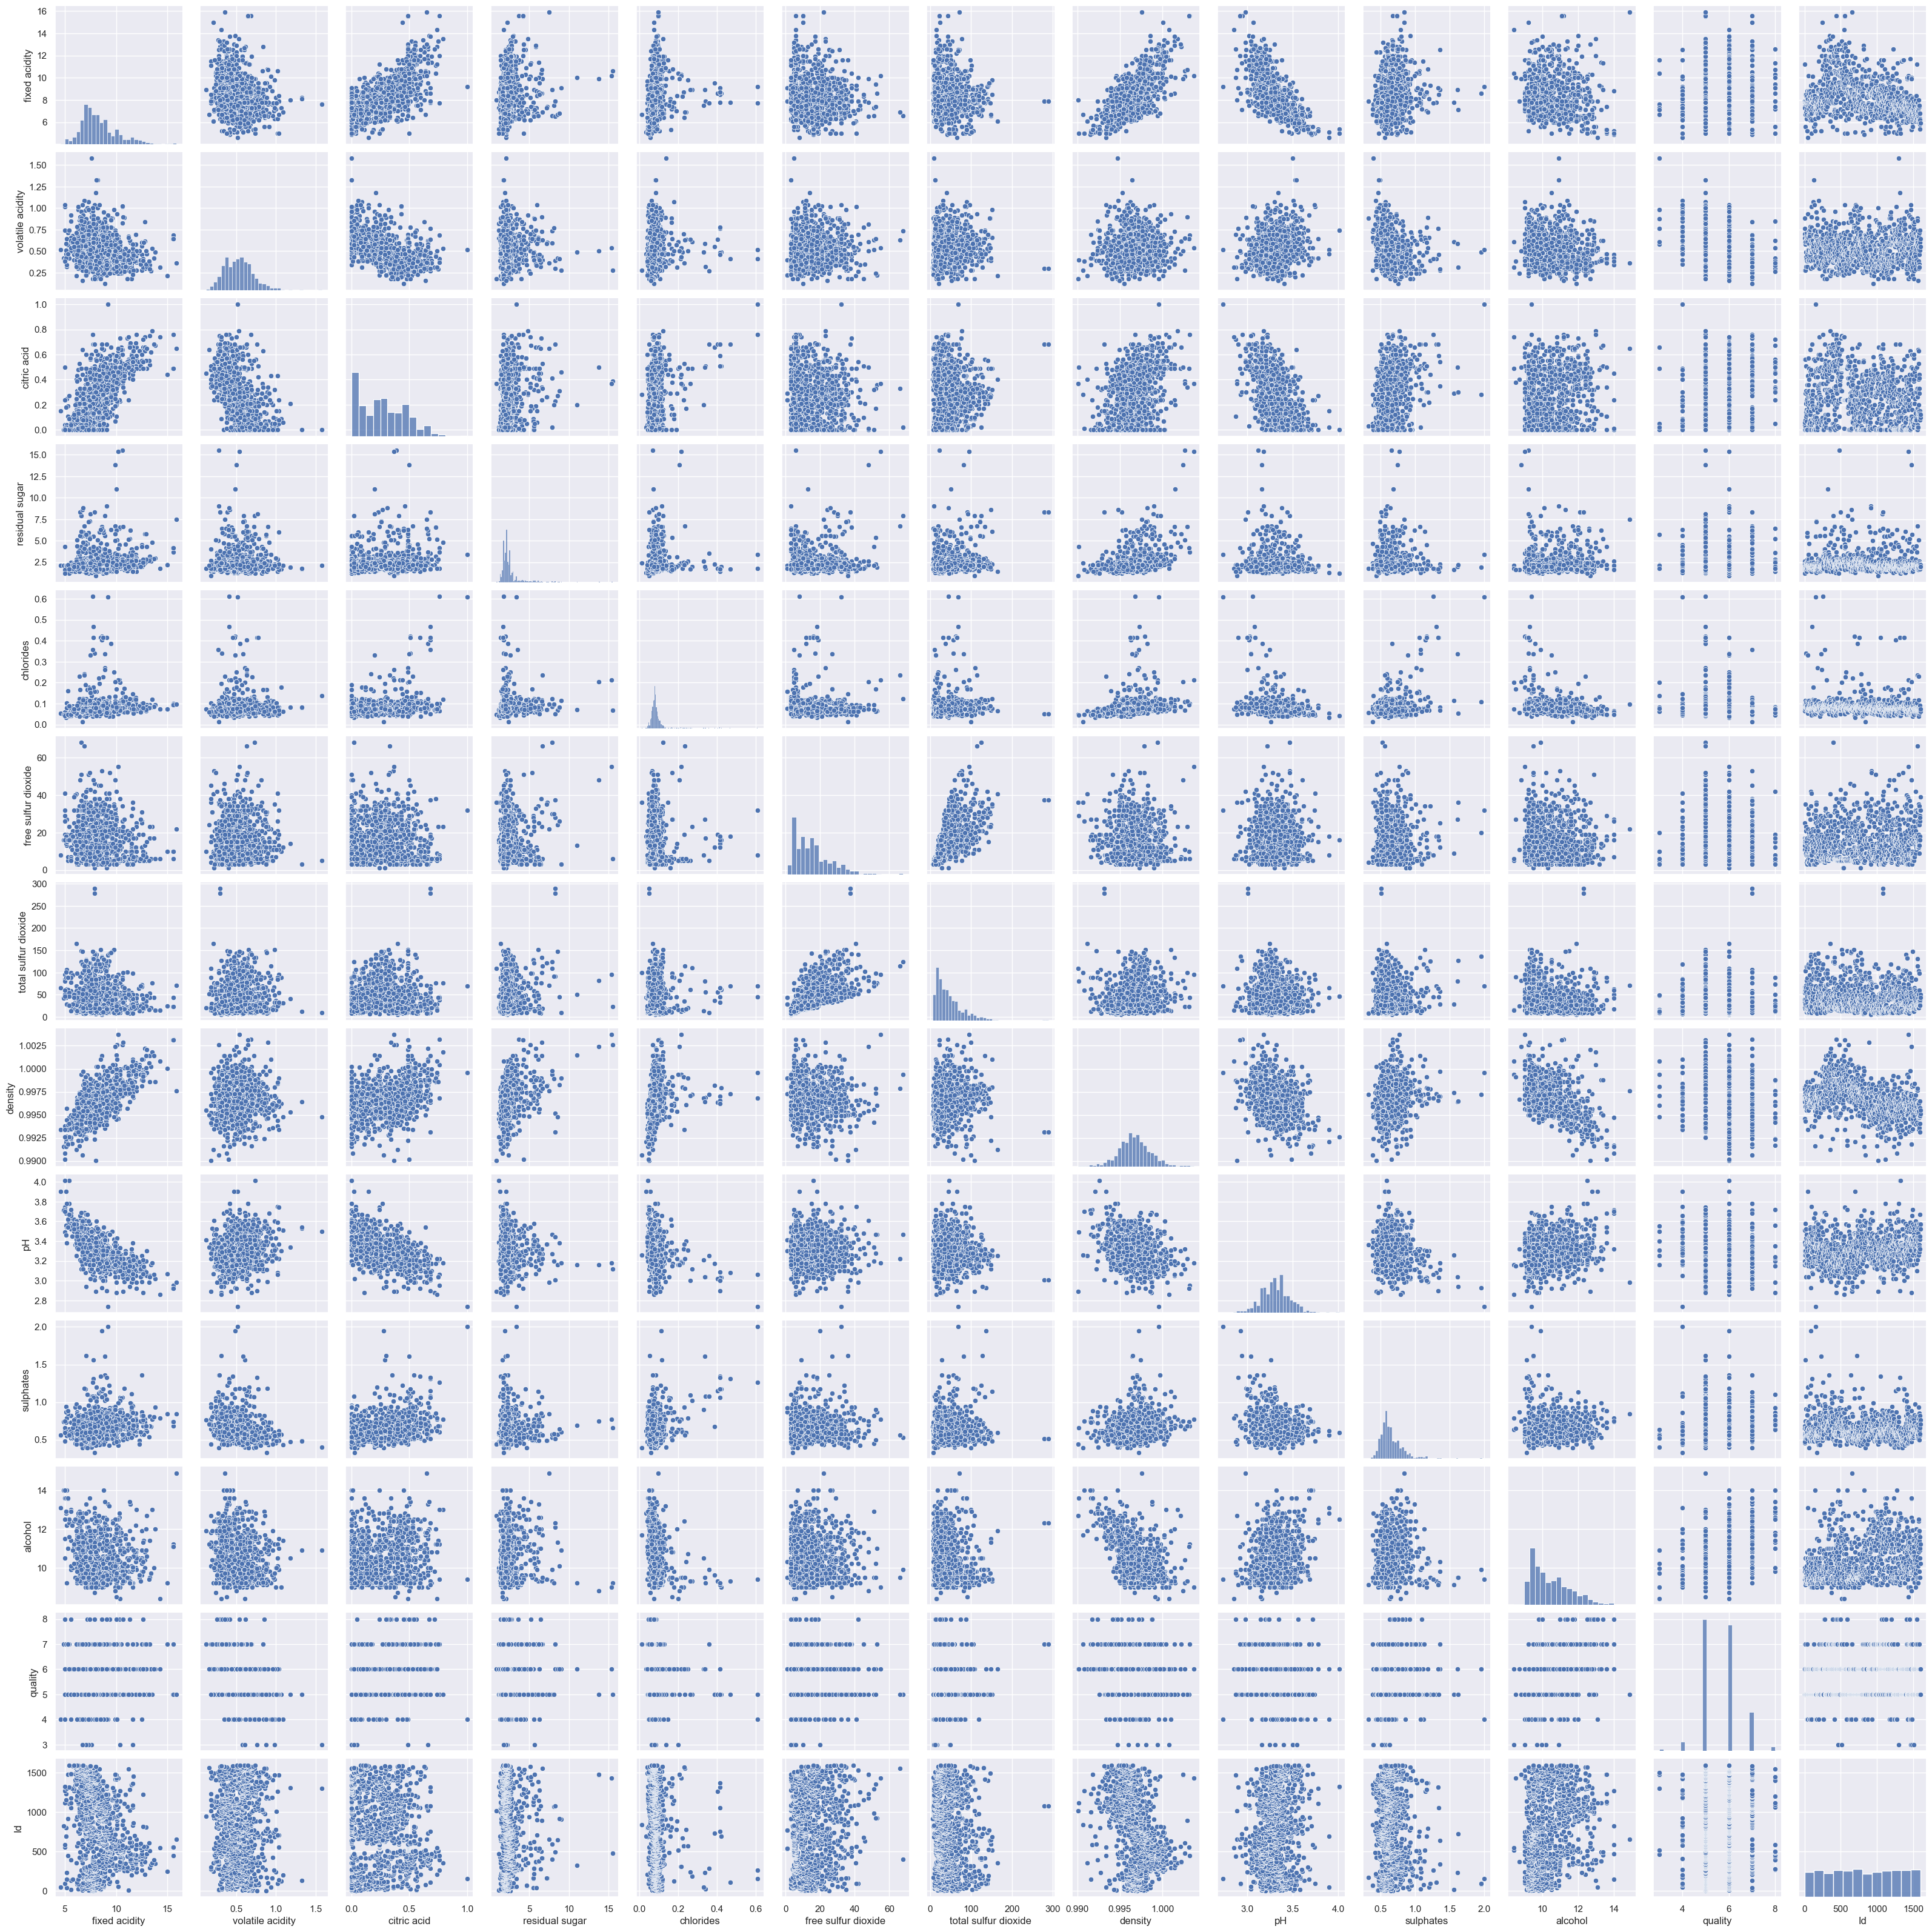

In [32]:
# Pair Plot:
sns.pairplot(data=df)

# Display the plot
plt.show()

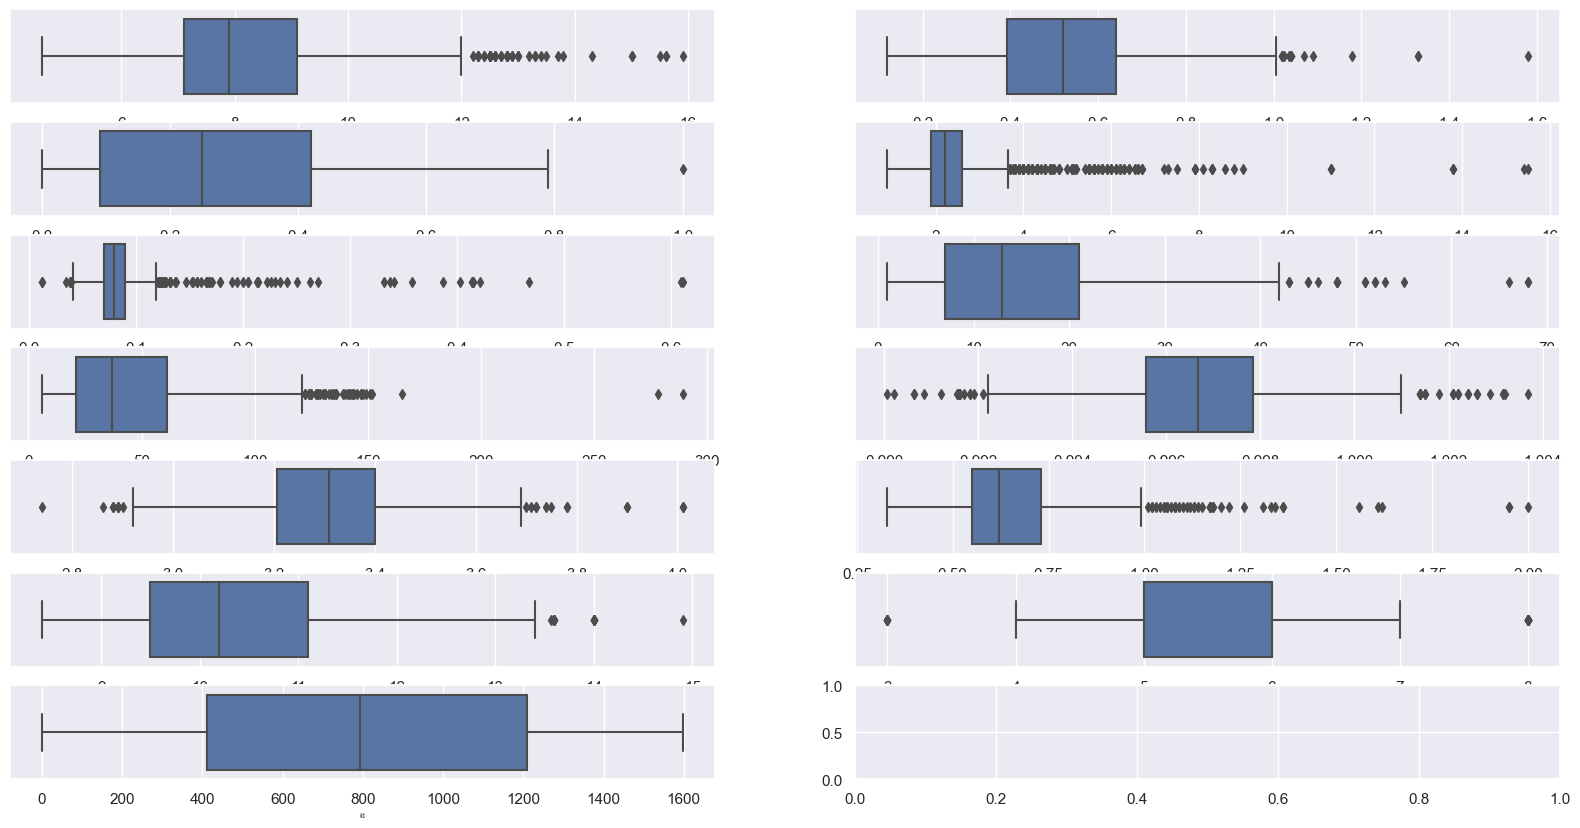

In [33]:
# Setting the figure size
fig,ax = plt.subplots(7,2,figsize =(20,10))

# Setting the figure size
for variable, subplot in zip(df.columns,ax.flatten()):
    z=sns.boxplot(x=df[variable],orient='h',whis=1.5,ax=subplot)
    z.set_xlabel(variable,fontsize = 5)
    

In [34]:
df.shape

(1143, 13)

In [35]:
# 1st Quantile of the data
Q1 = df.quantile(0.25)

# 3rd Quantile of the data
Q3 = df.quantile(0.75)

# Obtaining the Inter Quantile Range
IQR = Q3-Q1

IQR

fixed acidity             2.000000
volatile acidity          0.247500
citric acid               0.330000
residual sugar            0.700000
chlorides                 0.020000
free sulfur dioxide      14.000000
total sulfur dioxide     40.000000
density                   0.002275
pH                        0.195000
sulphates                 0.180000
alcohol                   1.600000
quality                   1.000000
Id                      798.500000
dtype: float64

In [36]:
# Removing the outliers 
df =df[~((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR))).any(axis =1)]

In [37]:
df.shape

(834, 13)

In [38]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Skewness : 0.27990655023366784


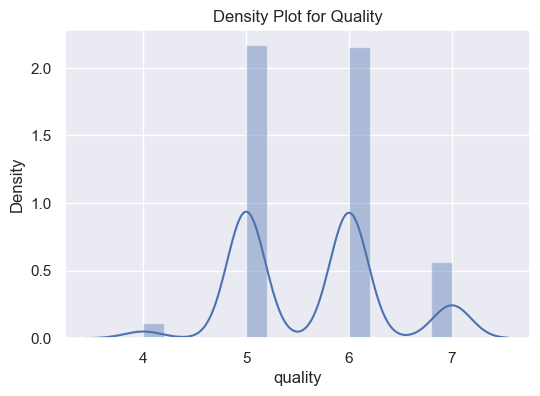

In [42]:
# Set the figure size:
plt.rcParams['figure.figsize']=[6,4]

# Distplot 
sns.distplot(df['quality'])

# Set the title:
plt.title('Density Plot for Quality')

# Set the y-label
plt.ylabel('Density')

print('Skewness :',df['quality'].skew())

# display the plot:
plt.show()

Skewness : -0.005394527271149935


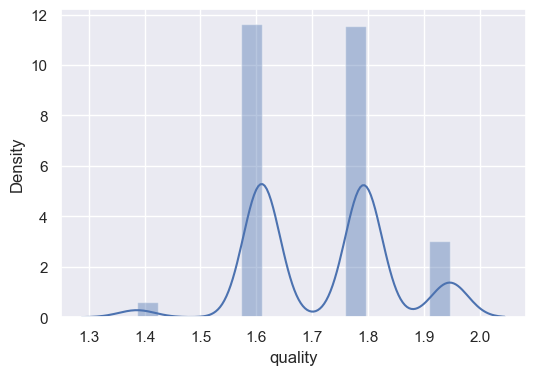

In [43]:
# Apply natural log transformation with (base 'e')
log_quality = np.log(df['quality'])

# coefficient of Skewness
print('Skewness :',log_quality.skew())

# distribution of log_transformed variable:
sns.distplot(log_quality)

# set label for y-axis:
plt.ylabel('Density')

# display the plot:
plt.show()

In [44]:
# Import the sklearn library:
# import the train_test_split module from sklearn:

import sklearn
from sklearn.model_selection import train_test_split

In [45]:
# select the Independent column
# By dropping the Target column
X =df.drop(['quality'], axis=1)

# select the target column:
Y =df['quality']

In [46]:
# Let us now split the dataset into test and train
# Test Size : The proportion of the data to be included in the testing set 
x_train,x_test,y_train,y_test = train_test_split(X,Y, test_size = 0.25,
                                                random_state = 100)

print('X_train :',x_train.shape)
print('X_test :',x_test.shape)
print('Y_train :',y_train.shape)
print('Y_test :',y_test.shape)

X_train : (625, 12)
X_test : (209, 12)
Y_train : (625,)
Y_test : (209,)


In [47]:
# From sklearn import standardscaler
from sklearn.preprocessing import StandardScaler

ss_train = StandardScaler()
x_train = ss_train.fit_transform(x_train)

ss_test = StandardScaler()
x_test = ss_test.fit_transform(x_test)

In [48]:
models = {}

#Random Forest:
from sklearn.ensemble import RandomForestClassifier
models['Random Forest'] = RandomForestClassifier()


In [49]:
# Support Vector Machines:
from sklearn.svm import LinearSVC
models['Support Vector Machines'] = LinearSVC()

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# creating an instance:
accuracy = {}

for key in models.keys():
    
    models[key].fit(x_train, y_train)
    
    predictions = models[key].predict(x_test)
    
    
    accuracy[key] = accuracy_score(predictions, y_test)
   

In [54]:
# Printing the accuracy score:

df_model = pd.DataFrame(index = models.keys(),
                       columns = ['Accuracy'])
df_model['Accuracy'] = accuracy.values()

df_model

,Accuracy
Random Forest,0.679426
Support Vector Machines,0.588517


### Summary

This project focused on predicting wine quality using the Random Forest algorithm, leveraging a dataset with various chemical and sensory attributes. The aim was to develop a robust model capable of accurately classifying wines into quality categories.

**Data Preprocessing:**
The dataset underwent preprocessing to handle missing values, standardize numerical features, and encode categorical variables. Exploratory data analysis (EDA) provided insights into the distribution of features, helping identify potential patterns.

**Feature Selection:**
Relevant features impacting wine quality were selected through feature importance analysis within the Random Forest model. This ensured the inclusion of key variables contributing to the predictive power of the model.

**Random Forest Model:**
The Random Forest algorithm, known for its ensemble learning approach, was employed for its ability to handle complex relationships and reduce overfitting. The dataset was split into training and testing sets, and the Random Forest model was trained on the former to predict wine quality.

**Model Evaluation:**
Evaluation metrics such as accuracy score is utilized to assess the model's performance. Cross-validation techniques were applied to ensure robustness and prevent overfitting.

**Results:**
The Random Forest model demonstrated high accuracy in predicting wine quality categories. Feature importance analysis highlighted the influential factors contributing to wine quality, providing valuable insights into the chemical and sensory attributes driving classification.

**Limitations and Future Work:**
Limitations included potential sensitivity to hyperparameter tuning and the need for a sufficiently large dataset. Future work could involve exploring ensemble methods, fine-tuning hyperparameters, and incorporating additional features for a more comprehensive analysis.

**Conclusion:**
In conclusion, the Random Forest algorithm proved effective in predicting wine quality, offering a reliable model for classification tasks. The insights gained contribute to a deeper understanding of the factors influencing wine quality, paving the way for further refinement and exploration in this domain.
